# 3 · Maps and merging: the regional study

24 random scenarios on a 64 km domain (`run.py regional`): every rain model, flow, evolution and
radar band, 19-176 links, 6-50 gauges, 4-60 PWS. 27 map products per scenario, scored against
the truth. Then the link counterfactual: the same scenarios with the links processed three ways.

In [1]:
import sys
import warnings
from pathlib import Path

sys.path.insert(0, str(Path.cwd().parent / "src"))
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, Markdown, display

from core import viz_style as vs
%matplotlib inline
vs.use_style()
pd.set_option("display.width", 160)
FIG = Path("../results/figures")
TAB = Path("../results/tables")

In [2]:
maps = pd.read_csv(TAB / "regional/maps.csv")
scen = pd.read_csv(TAB / "regional/scenarios.csv")
radar = maps[maps.method == "radar"].set_index("scenario").nrmse
maps["beats_radar"] = maps.nrmse < maps.scenario.map(radar)
summary = maps.groupby(["family", "method"]).agg(nrmse=("nrmse", "median"), beats_radar=("beats_radar", "mean"),
                                                 corr=("corr", "median"), bias=("rel_bias", "median"),
                                                 csi=("csi", "median"))
summary.sort_values("nrmse").round(2)

nrmse  beats_radar  corr  bias   csi
family         method                                                        
radar adjusted mfb [gauges]               0.43         0.67  0.90 -0.07  0.87
               add [gauges]               0.44         1.00  0.94 -0.00  0.87
               idw_add [gauges]           0.47         0.62  0.92  0.01  0.85
               add [links+gauges]         0.50         0.75  0.92 -0.01  0.83
               mul [links+gauges]         0.51         0.96  0.93 -0.05  0.86
               okrig_add [gauges]         0.51         0.67  0.92 -0.01  0.83
               mul [gauges]               0.52         1.00  0.93 -0.05  0.87
               ked [links+gauges]         0.56         0.38  0.86  0.16  0.78
               mul [links]                0.56         0.67  0.93 -0.04  0.85
               ked [gauges]               0.56         0.38  0.90  0.20  0.74
               mfb [links+gauges]         0.56         0.46  0.90 -0.02  0.82
               idw_add [links+gauges]     0.59         0.62  0.91  0.05  0.80
               okrig_add [links+gauges]   0.60         0.62  0.91  0.04  0.81
               idw_mul [gauges]           0.61         0.42  0.88 -0.05  0.85
radar only     radar                      0.62         0.00  0.93 -0.06  0.85
radar adjusted add [links]                0.64         0.38  0.87  0.03  0.77
               okrig_add [links]          0.65         0.33  0.84  0.08  0.75
               idw_add [links]            0.66         0.25  0.84  0.10  0.74
               mfb [links]                0.75         0.21  0.86  0.03  0.79
               ked [links]                0.84         0.12  0.76  0.08  0.76
               idw_mul [links+gauges]     0.85         0.21  0.80  0.03  0.78
no radar       idw gauges                 0.91         0.17  0.67 -0.10  0.63
               idw links+gauges+pws       0.98         0.12  0.66 -0.08  0.57
               idw links+gauges           1.04         0.12  0.60 -0.03  0.53
               idw links                  1.25         0.00  0.18  0.04  0.36
               gmz links                  1.25         0.00  0.19  0.05  0.36
radar adjusted idw_mul [links]            2.52         0.00  0.57  0.47  0.68

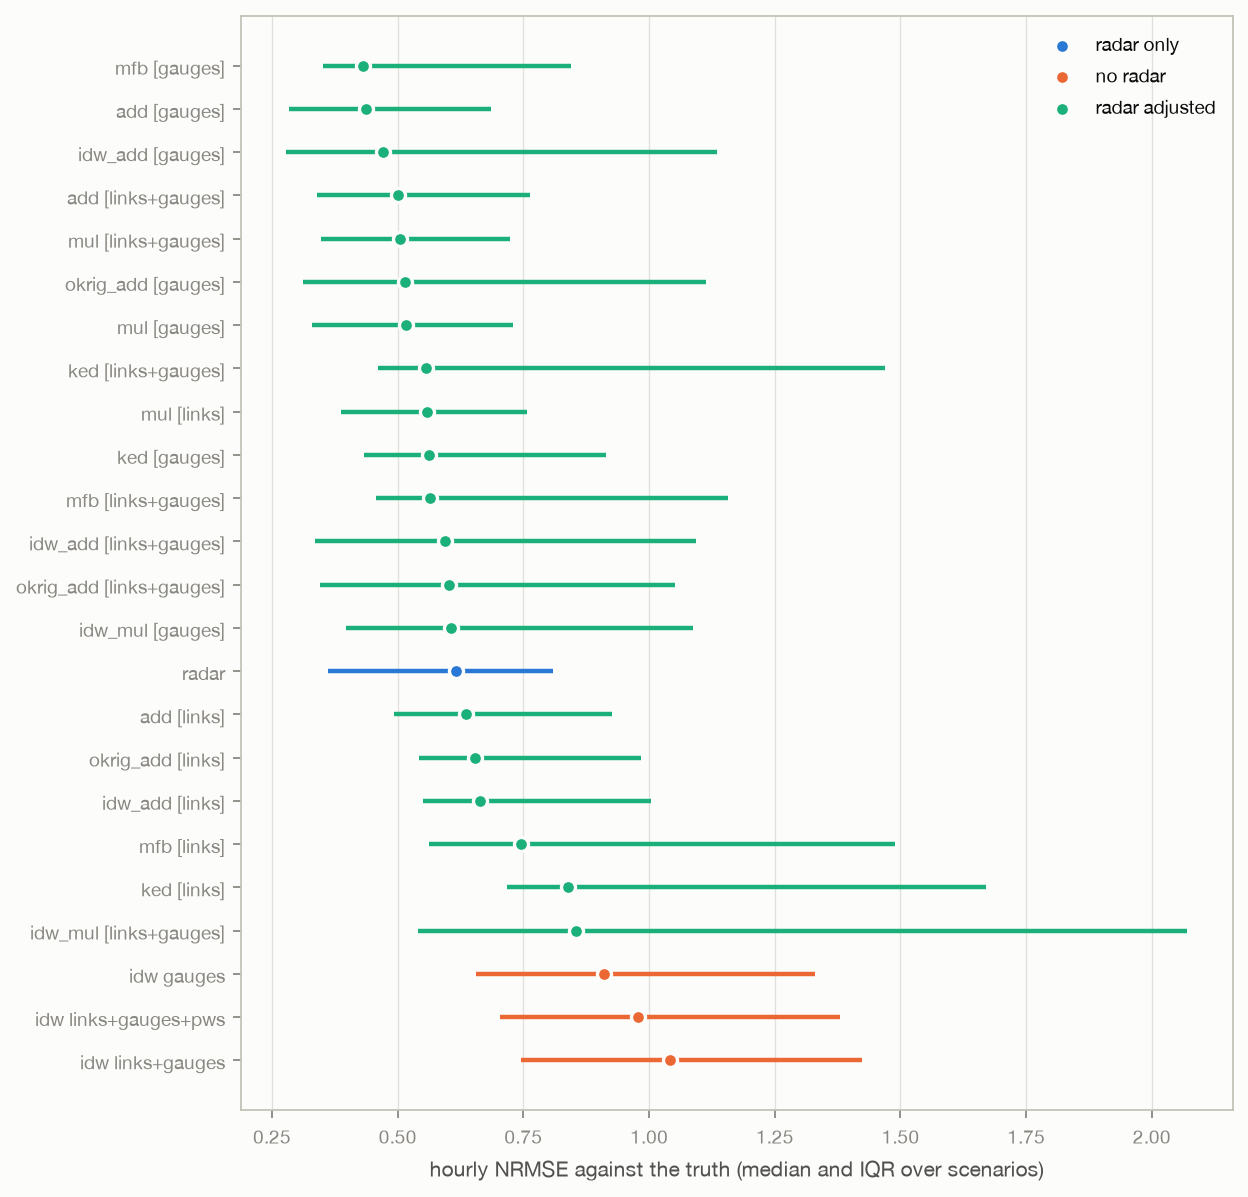

In [3]:
display(Image(str(FIG / "fig05_maps.png")))

## By regime

Convective and organised rain is two to three times harder than widespread rain, for every method.

In [4]:
conv = ("convective_cells", "clustered_storms", "squall_line", "frontal")
m = maps.merge(scen[["scenario", "model", "radar_band"]], on="scenario")
m["regime"] = np.where(m.model.isin(conv), "convective / organised", "widespread")
keep = ["radar", "add [gauges]", "add [links+gauges]", "mul [links+gauges]", "ked [links+gauges]",
        "add [links]", "idw links+gauges+pws"]
m[m.method.isin(keep)].pivot_table(index="method", columns="regime", values="nrmse", aggfunc="median").round(2)

regime,convective / organised,widespread
method,,
add [gauges],1.05,0.31
add [links+gauges],1.16,0.36
add [links],1.71,0.53
idw links+gauges+pws,1.95,0.74
ked [links+gauges],1.53,0.47
mul [links+gauges],1.24,0.36
radar,1.31,0.40


In [5]:
m[m.method == "radar"].groupby("radar_band")[["nrmse", "rel_bias"]].median().round(2)

,nrmse,rel_bias
radar_band,,
C,0.49,-0.01
S,0.50,0.22
X,0.79,-0.42


## Do the links add anything to the gauges?

Paired by scenario: the same method with and without the links.

In [6]:
p = maps.pivot_table(index="scenario", columns="method", values="nrmse")
pd.DataFrame({f"{a} vs {b}": {"links better in": f"{((p[a] - p[b]) < 0).mean():.0%}",
                              "median change": round((p[a] - p[b]).median(), 3)}
              for a, b in [("add [links+gauges]", "add [gauges]"), ("mul [links+gauges]", "mul [gauges]"),
                           ("ked [links+gauges]", "ked [gauges]"), ("okrig_add [links+gauges]", "okrig_add [gauges]")]}).T

,links better in,median change
add [links+gauges] vs add [gauges],21%,0.043
mul [links+gauges] vs mul [gauges],38%,0.009
ked [links+gauges] vs ked [gauges],50%,0.007
okrig_add [links+gauges] vs okrig_add [gauges],42%,0.015


## What the links' errors cost

`run.py links`: the first eight scenarios again, with the links retrieved from every raw sample,
with the study's chain, and error-free.

In [7]:
cf = pd.read_csv(TAB / "link_counterfactual.csv")
t = cf.pivot_table(index="method", columns="links", values="nrmse", aggfunc="median").round(3)
t.loc["path-average bias"] = cf.groupby("links").link_bias.median().round(3)
t

links,default,ideal,no wet/dry
method,,,
add [gauges],0.594,0.594,0.594
add [links+gauges],0.576,0.562,0.571
add [links],0.654,0.690,0.725
idw links,1.568,1.547,1.536
idw links+gauges,1.252,1.246,1.250
ked [links+gauges],0.717,0.719,0.795
mul [links+gauges],0.640,0.622,0.621
okrig_add [links+gauges],0.666,0.639,0.670
radar,0.738,0.738,0.738
